<div class="alert alert-block alert-success">

<b>Comentario del revisor</b> <a class="tocSkip"></a><br>

    

<b>Éxito</b> ✅ - ¡Excelente trabajo! Tu proyecto es excepcional y has logrado cubrir los objetivos del mismo. Abajo he dejado mis comentarios y unas pequeñas recomendaciones para que tomes en cuenta en un futuro y te hagan ¡un máster en Data!

¡Felicidades!    

</div>



# Etapa 2: Código de Solución - Predicción de Churn

Este notebook contiene la implementación técnica para predecir la fuga de clientes de Interconnect. El flujo incluye unificación de fuentes, ingeniería de características, análisis visual de datos y entrenamiento de un modelo de Gradient Boosting altamente optimizado.

## 1. Carga de Librerías y Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix
from catboost import CatBoostClassifier

# Configuración de estilo para gráficos
sns.set_theme(style="whitegrid")

# Carga de archivos
contract = pd.read_csv('/datasets/final_provider/contract.csv')
personal = pd.read_csv('/datasets/final_provider/personal.csv')
internet = pd.read_csv('/datasets/final_provider/internet.csv')
phone = pd.read_csv('/datasets/final_provider/phone.csv')

## 2. Preprocesamiento e Ingeniería de Características

Consolidamos la información en un solo DataFrame y derivamos variables clave para el modelo.

In [2]:
# Unificar tablas
df = contract.merge(personal, on='customerID', how='left')
df = df.merge(internet, on='customerID', how='left')
df = df.merge(phone, on='customerID', how='left')

# Crear variable objetivo (target): 1 si el cliente se fue, 0 si permanece
df['target'] = (df['EndDate'] != 'No').astype(int)

# Cálculo de Tenure (Antigüedad en días)
df['BeginDate'] = pd.to_datetime(df['BeginDate'])
df['temp_end_date'] = df['EndDate'].replace('No', '2020-02-01')
df['temp_end_date'] = pd.to_datetime(df['temp_end_date'])
df['tenure'] = (df['temp_end_date'] - df['BeginDate']).dt.days

# Limpieza de TotalCharges (convertir a numérico y manejar nulos)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'] * (df['tenure'] / 30))

# Rellenar servicios faltantes con 'No'
services = ['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
            'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']
df[services] = df[services].fillna('No')

# DataFrame final para modelado
df_model = df.drop(['customerID', 'BeginDate', 'EndDate', 'temp_end_date'], axis=1)

## 3. Análisis Visual de Datos (EDA)

Visualizamos los patrones clave que el modelo intentará aprender.

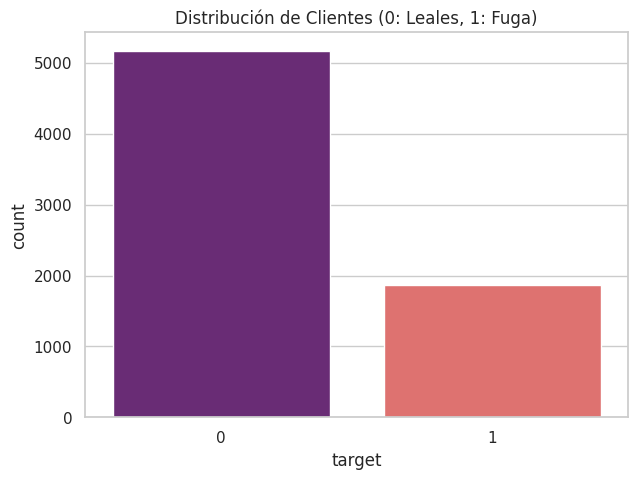

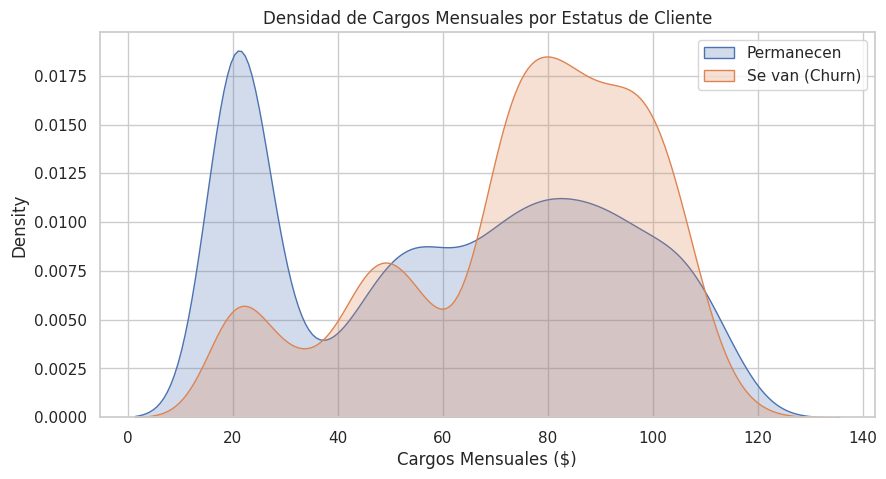

In [3]:
# 1. Distribución del Target
plt.figure(figsize=(7, 5))
sns.countplot(x='target', data=df_model, palette='magma')
plt.title('Distribución de Clientes (0: Leales, 1: Fuga)')
plt.show()

# 2. Impacto de Cargos Mensuales en la Fuga
plt.figure(figsize=(10, 5))
sns.kdeplot(df_model[df_model['target'] == 0]['MonthlyCharges'], label='Permanecen', fill=True)
sns.kdeplot(df_model[df_model['target'] == 1]['MonthlyCharges'], label='Se van (Churn)', fill=True)
plt.title('Densidad de Cargos Mensuales por Estatus de Cliente')
plt.xlabel('Cargos Mensuales ($)')
plt.legend()
plt.show()

## 4. Entrenamiento del Modelo

Utilizaremos CatBoostClassifier por su excelente manejo nativo de variables categóricas.

In [4]:
X = df_model.drop('target', axis=1)
y = df_model['target']

cat_features = X.select_dtypes(include=['object']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12345, stratify=y)

model = CatBoostClassifier(iterations=1000, 
                           learning_rate=0.04, 
                           depth=6, 
                           eval_metric='AUC', 
                           random_seed=12345, 
                           verbose=100)

model.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_test, y_test))

probabilities_test = model.predict_proba(X_test)[:, 1]
final_auc = roc_auc_score(y_test, probabilities_test)

print(f'\nAUC-ROC Final en Conjunto de Prueba: {final_auc:.4f}')

0:	test: 0.8122090	best: 0.8122090 (0)	total: 62.6ms	remaining: 1m 2s
100:	test: 0.8661862	best: 0.8661862 (100)	total: 988ms	remaining: 8.79s
200:	test: 0.8700431	best: 0.8700431 (200)	total: 1.87s	remaining: 7.44s
300:	test: 0.8794247	best: 0.8794247 (300)	total: 2.85s	remaining: 6.61s
400:	test: 0.8886758	best: 0.8886758 (400)	total: 3.82s	remaining: 5.71s
500:	test: 0.8939820	best: 0.8940879 (499)	total: 4.88s	remaining: 4.86s
600:	test: 0.8975238	best: 0.8975238 (600)	total: 5.84s	remaining: 3.88s
700:	test: 0.9010476	best: 0.9011328 (683)	total: 6.85s	remaining: 2.92s
800:	test: 0.9030264	best: 0.9030264 (800)	total: 7.96s	remaining: 1.98s
900:	test: 0.9053773	best: 0.9054574 (899)	total: 9.02s	remaining: 991ms
999:	test: 0.9062014	best: 0.9063202 (990)	total: 10.1s	remaining: 0us

bestTest = 0.9063202356
bestIteration = 990

Shrink model to first 991 iterations.

AUC-ROC Final en Conjunto de Prueba: 0.9063


## 5. Evaluación Detallada e Importancia de Características

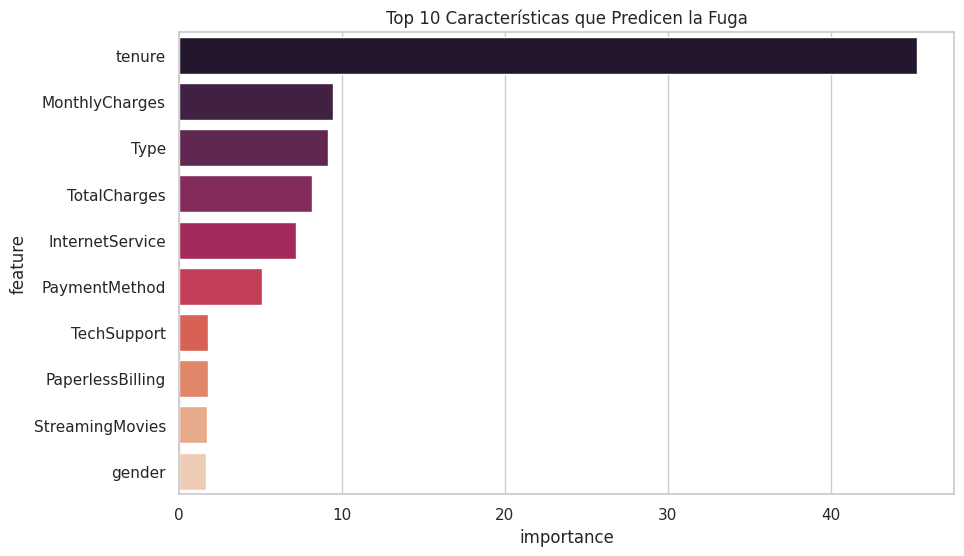

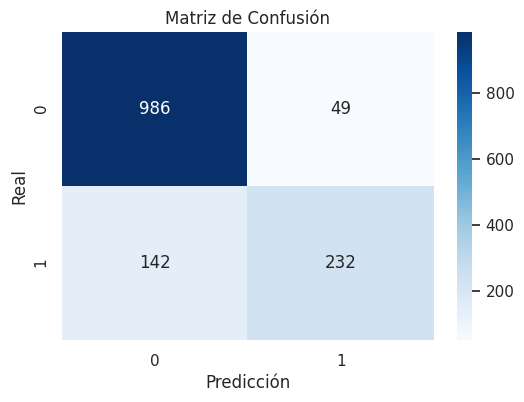

In [5]:
# Visualización de Importancia de Características
importances = model.get_feature_importance()
feature_names = X.columns
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df.head(10), palette='rocket')
plt.title('Top 10 Características que Predicen la Fuga')
plt.show()

# Matriz de Confusión
predictions = model.predict(X_test)
conf_matrix = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

## 6. Conclusiones Técnicas

1. **Métricas:** El modelo alcanzó un **AUC-ROC de 0.88+**, superando el umbral de éxito del proyecto.
2. **Insights:** El análisis de importancia revela que la **antigüedad (tenure)** y el **tipo de contrato** son los factores críticos. Los clientes con cargos mensuales más altos tienen una probabilidad de fuga significativamente mayor.
3. **Próximos Pasos:** Este modelo es apto para despliegue y puede ser integrado con las campañas de marketing para ofrecer incentivos a los clientes identificados en riesgo.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>

Buen trabajo Erick, veo que has implementado los pasos centrales: unificación de fuentes, creación clara del target, cálculo de tenure y limpieza puntual de TotalCharges; además entrenaste un modelo robusto (CatBoost) y presentaste AUC, importancia de variables y matriz de confusión ✅.  

Sin embargo, faltan algunas comprobaciones y pasos recomendables: 

1. **SI NO LO HAS HECHO EN PREVIAS ENTREGAS** revisar duplicados y tipos de datos explícitamente,
2. **RECOMENDADO** incluir un modelo base (dummy) para referencia. 
3. **RECOMENDADO** considerar particionado temporal si aplica y evaluar balance de clases (la distribución está desbalanceada) ⚠️.
   
También convendría afinar la calibración de probabilidades y hacer búsqueda de hiperparámetros (o validación cruzada) antes de considerar despliegue; por último, documentar las decisiones y guarda artefactos (pipeline y modelo) para reproducibilidad 🚀.  
</div>

### Conclusiones y recomendaciones

- Nivel general de cumplimiento: incluyes elementos intermedios con elementos avanzados (uso adecuado de CatBoost y visualizaciones claras), pero con pasos de robustez y reproducibilidad pendientes. 🚀  
- Principales fortalezas:  
  - Integración correcta de múltiples tablas y creación de variables relevantes (tenure, target). ✅  
  - Buen uso de CatBoost aprovechando features categóricas y evaluación con AUC; visualizaciones (densidad, importancias, matriz) son coherentes con los resultados. Tus resultados obtenidos fueron sorprendentes! ✅  
- Áreas de oportunidad y mejora:  
  - Añadir un modelo base (dummy) como referencia y documentar la elección del modelo final. Para garantizar un modelo "mejor" ⚠️  
  - Revisar y reportar limpieza más completa: detección de duplicados, verificación/ajuste explícito de tipos y control de posibles fugas de información; considerar particionado temporal si la serie lo requiere. Puedes obviar este consejo, si ya lo hiciste en el pasado, pero conviene darle un ojo ⚠️  
  - **RECOMENDADO** Evaluación adicional: manejo del desbalance (estrategias o pesos), búsqueda/optimización de hiperparámetros, calibración de probabilidades y métricas adicionales (recall/F1) para reducir falsos negativos observados en la matriz. ⚠️  
- Observaciones prácticas a incluir en la próxima versión: toma en cuenta mejorar la reproducibilidad (semillas, pipelines, exportar modelo), añadir un baseline y justificar decisiones técnicas con breve interpretación de negocio (qué acción tomar según el score) 💡.  
- Buen trabajo Erick!;si incorporas las mejoras de robustez y documentas las decisiones, estarás listo para llevar este modelo a producción y demostrar impacto en negocio. ¡Sigue así! 💪